# Order Book Signals on Bond & Equity Calendar Spreads

## Setup

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, '..')

import polars as pl
import numpy as np
from plotnine import *
from plotnine.themes import theme_bw
import pandas as pd
from src.pipeline import (
    build_datasets, generate_signals, attach_leg_signals,
    TRAIN_YEARS, VAL_YEARS, TEST_YEARS, YEAR_LABEL, TRAIN_END
)

pl.Config.set_tbl_cols(30)
pl.Config.set_tbl_rows(20)


polars.config.Config

In [2]:
df_cs, df_combined = build_datasets(env_path='../.env')   # or pass session=snowpark to reuse a connection

binned   : (13901208, 14)  (futures: 9,390,042  |  spreads: 4,511,166)
qmap     : (18, 5)
sec_meta : (1106, 3)
df_cs       : (608626, 29)
df_fut      : (1218591, 27)
df_combined : (1827217, 29)


In [3]:
df_fut = df_combined.join(df_cs, on=['security'], how='anti')
df_signals = generate_signals(df_cs, df_fut, train_end=TRAIN_END)                       # replaces cells 10–11
# Augment each spread bin with the BUY/SELL leg outright OBI/STV (resolved via
# IS_CONVENTION_BUY_NEAR) -> adds buy_obi / buy_stv / sell_obi / sell_stv.
df_signals = attach_leg_signals(df_signals, df_combined)

c:\Users\junwu.wang\Downloads\ip1\notebooks\..\src\pipeline.py:286: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided


In [4]:
from src.ordered_logit import split_tick_constrained

df_signals_tu, df_signals_tc = split_tick_constrained(df_signals)
df_signals_tc = df_signals_tc.filter(pl.col('is_roll_period'))
df_signals_tc.describe()

statistic,qcode,security,bin_start_time,publication_date,bid_size_start,ask_size_start,bid_start,ask_start,volume,signed_volume,twa_ask_size,twa_bid_size,high,low,…,delta_la,obi,futures_price,delta_p_bp,ofi,stv,noi,days_before,_tick,buy_identifier,sell_identifier,buy_obi,buy_stv,sell_obi,sell_stv
str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64
"""count""","""91879""","""91879""","""91879""","""91879""",91879.0,91879.0,91879.0,91879.0,91879.0,91879.0,91879.0,91879.0,91873.0,91873.0,…,91879.0,91879.0,91879.0,91879.0,91879.0,91879.0,91879.0,91879.0,91879.0,"""91879""","""91879""",91878.0,88636.0,91869.0,88269.0
"""null_count""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,6.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""0""",1.0,3243.0,10.0,3610.0
"""mean""",null,null,"""13:02:48.812242""","""2023-01-04 06:46:19.960600""",31728.4992,33873.408494,1.334977,1.391012,2406.653316,69.33025,33842.887411,31692.910232,1.396943,1.330215,…,-49.404064,-0.022471,701.172348,0.003551,0.009482,0.065047,-0.004613,3.080051,0.025312,null,null,-0.004086,0.125958,0.007855,0.092359
"""std""",null,null,null,null,59600.662358,64159.553381,13.600756,13.643567,7057.287188,5081.222134,63958.711284,59381.125323,13.66129,13.586258,…,7830.920375,0.413671,1378.850474,0.55798,2.143146,1.241516,1.227072,1.379715,0.038548,null,null,0.475845,1.35532,0.56974,1.234929
"""min""","""BF""","""DU2020H/2020M Comdty""","""08:00:00""","""2020-01-23""",1.0,1.0,-44.75,-44.5,0.0,-322178.0,1.21024,1.543153,-44.5,-44.75,…,-337510.0,-0.999972,104.80313,-22.240716,-159.148624,-38.188639,-20.855156,1.0,0.0025,"""DU2020H Comdty""","""DU2020M Comdty""",-0.999713,-37.753718,-0.999774,-20.96113
"""25%""",null,null,"""10:45:00""","""2021-06-15""",2880.0,2838.0,-0.46,-0.45,139.0,-183.0,3063.174043,3053.149993,-0.45,-0.465,…,-470.0,-0.264025,120.749076,0.0,-0.195558,-0.578107,-0.660336,2.0,0.005,null,null,-0.357143,-0.777914,-0.467128,-0.710424
"""50%""",null,null,"""13:05:00""","""2022-12-06""",10734.0,11743.0,0.28,0.3,545.0,6.0,11979.40308,10891.21131,0.3,0.28,…,-33.0,-0.025975,151.476529,0.0,0.00448,0.118704,0.0,3.0,0.01,null,null,0.0,0.286691,0.0,0.197089
"""75%""",null,null,"""15:20:00""","""2024-06-19""",34961.0,37656.0,0.99,1.0,2177.0,276.0,37211.499803,34738.34117,1.0,0.99,…,342.0,0.216823,322.372165,0.0,0.212216,0.687266,0.641997,4.0,0.025,null,null,0.346644,0.942267,0.492063,0.856089
"""max""","""SV""","""VG2025Z/2026H Index""","""17:55:00""","""2025-12-29""",632904.0,801681.0,84.75,85.0,427874.0,292620.0,792707.035847,631348.721553,85.0,84.75,…,470683.0,0.999938,5774.311321,29.517418,123.941714,23.983485,19.781134,10.0,0.125,"""VG2025Z Index""","""VG2026H Index""",0.999581,39.01634,0.999893,27.422428


In [17]:
# List of columns to analyze
columns_to_check = ['noi', 'ofi', 'stv', 'buy_stv', 'sell_stv']
proportions = {}

# Calculate proportion for each column
for col_name in columns_to_check:
    # Calculate mean and standard deviation
    mean_val = df_signals_tc[col_name].mean()
    std_val = df_signals_tc[col_name].std()
    
    # Filter rows where the absolute difference from mean is >= 5 * std
    # We use (pl.col(col_name) - mean_val).abs() to check the distance
    count = df_signals_tc.filter(
        (pl.col(col_name) - mean_val).abs() >= (6 * std_val)
    ).height
    
    # Calculate proportion
    proportion = count / df_signals_tc.height
    proportions[col_name] = proportion

# Display the results
for col, prop in proportions.items():
    print(f"Proportion of outliers (>= 5 std) in {col}: {prop:.4%}")

Proportion of outliers (>= 5 std) in noi: 0.1600%
Proportion of outliers (>= 5 std) in ofi: 0.6857%
Proportion of outliers (>= 5 std) in stv: 0.2024%
Proportion of outliers (>= 5 std) in buy_stv: 0.1524%
Proportion of outliers (>= 5 std) in sell_stv: 0.0871%


In [18]:
# Define the range multiplier (k)
k = 6
columns_to_clip = ['noi', 'ofi', 'stv', 'buy_stv', 'sell_stv']

# Create a list of expressions to apply clipping
clipping_expressions = []

for col in columns_to_clip:
    # Calculate statistics
    mean_val = df_signals_tc[col].mean()
    std_val = df_signals_tc[col].std()
    
    # Calculate the bounds: [mean - k * std, mean + k * std]
    lower_bound = mean_val - (k * std_val)
    upper_bound = mean_val + (k * std_val)
    
    # Create the clipping expression
    clipping_expressions.append(
        pl.col(col).clip(lower_bound, upper_bound)
    )

# Apply the clipping to the DataFrame
df_signals_tc = df_signals_tc.with_columns(clipping_expressions)

# Tick-constrained curve groups

Tick-constrained groups trade on a near-discrete price grid, so $\Delta P_t$ is cleaned to the
ordered set $\{-2, 0, +2\}$ (neighbour-context rules applied within each `[security, date]`
session over the full 2021-2025 sample) and modelled with a **class-weighted ordered logit**.

**Out-of-sample protocol.** Both the contemporaneous and the 1-step-ahead models are
- **trained** on 2021-2023 only, weighting the $\pm2$ minority tails by their train inverse-frequency;
- **tuned** on validation (2024) — the $-2$ and $+2$ decision thresholds are chosen
  **independently**, each maximising that tail's **F$_\beta$** (default $\beta = 0.5$, i.e.
  precision-weighted) rather than using naive arg-max-probability assignment;
- **evaluated** on the held-out test set (2025) with the validation-selected thresholds.

In [7]:
from src.ordered_logit import clean_delta_p_tc

df_signals_tc_clean = clean_delta_p_tc(df_signals_tc)
counts = df_signals_tc_clean['delta_p'].value_counts(sort=True)
print(counts)

shape: (3, 2)
┌─────────┬───────┐
│ delta_p ┆ count │
│ ---     ┆ ---   │
│ i32     ┆ u32   │
╞═════════╪═══════╡
│ 0       ┆ 80714 │
│ 2       ┆ 5702  │
│ -2      ┆ 5463  │
└─────────┴───────┘


## OOS Setup & Helpers (Tick-Constrained)

The model, threshold tuning and reporting helpers live in **`src/ordered_logit.py`** and are imported
above, so this notebook and the walk-forward backtest cannot drift apart:
- `fit_ordered_logit` — fit on **train (2021-2023)** with **cluster-robust SE** (clustered on the
  `[security, date]` session, so the stacked panel does not induce spurious dependence at
  security boundaries), then predict class probabilities for train / val / test;
- `tune_thresholds` — pick the $-2$ and $+2$ decision boundaries **independently** on
  **validation (2024)**, each maximising that tail's **F$_\beta$** (one-vs-rest; `beta < 1`
  favours precision);
- `assign_classes` — apply the two tuned tail thresholds (the more probable tail wins if both
  fire);
- `pr_threshold_df` / `confusion_tile` — plotnine precision-recall and confusion-matrix plots;
- `report_all_splits` — classification reports (precision / recall / F1 / support) per split.

In [8]:
from src.ordered_logit import (
    CATS, TC_FEATURES, DEFAULT_BETA,
    fit_ordered_logit, tune_thresholds, assign_classes,
    pr_threshold_df, report_all_splits, confusion_tile,
)
from sklearn.metrics import fbeta_score
from datetime import date

# F-beta for the per-tail threshold tuning. beta < 1 favours PRECISION over recall (a tail
# signal being right matters more than catching every tail). Vary it for ablation studies.
BETA = DEFAULT_BETA   # = 0.5

# Convert the pipeline's year-list split constants to (start, end) date pairs for fit_ordered_logit.
def _years_to_dates(years):
    return date(min(years), 1, 1), date(max(years), 12, 31)

TRAIN_SPLIT = _years_to_dates(TRAIN_YEARS)
VAL_SPLIT   = _years_to_dates(VAL_YEARS)
TEST_SPLIT  = _years_to_dates(TEST_YEARS)

## Contemporary Baseline: Ordered Logistic Regression (Tick-Constrained)

Class-weighted ordered logit with **cluster-robust** standard errors (clustered on the
`[security, date]` session, not a linear HAC across the stacked panel), **fit on train (2021-2023)**:

$$\Pr(\Delta P_t \le k) = \sigma(\alpha_k - \mathbf{x}_t^\top \boldsymbol{\beta}), \quad k \in \{-2, 0\}$$

Explanatory variables $\mathbf{x}_t = [OBI_t,\ NOI_t,\ STV_t]$; target $\Delta P_t \in \{-2, 0, 2\}$.
The tail-vs-majority decision threshold is tuned on validation (2024) and applied to test (2025).

In [9]:
res_contemp, data_contemp, _ = fit_ordered_logit(
    df_signals_tc_clean, TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT,
    target_col='delta_p', label='Contemporaneous (tick-constrained)', verbose=True, feature_cols=['obi', 'ofi', 'stv']
)

=== Contemporaneous (tick-constrained):  delta_p ~ obi + ofi + stv  (train n=62,386, clusters=564, class_weight on ±2 = 11.3x) ===
train class counts: {-2: 4492, 0: 53178, 2: 4716}
                          WeightedOrderedModel Results                          
Dep. Variable:                        y   Log-Likelihood:                -95792.
Model:             WeightedOrderedModel   AIC:                         1.916e+05
Method:              Maximum Likelihood   BIC:                         1.916e+05
Date:                  Wed, 17 Jun 2026                                         
Time:                          10:54:52                                         
No. Observations:                 62386                                         
Df Residuals:                     62381                                         
Df Model:                             3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------

c:\Users\junwu.wang\miniforge3\envs\ip1\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals


Validation tail thresholds (β=0.5):  -2 → 0.950 (Fβ=0.5027)  |  +2 → 0.950 (Fβ=0.4813)   vs  arg-max-prob macro-Fβ = 0.4711


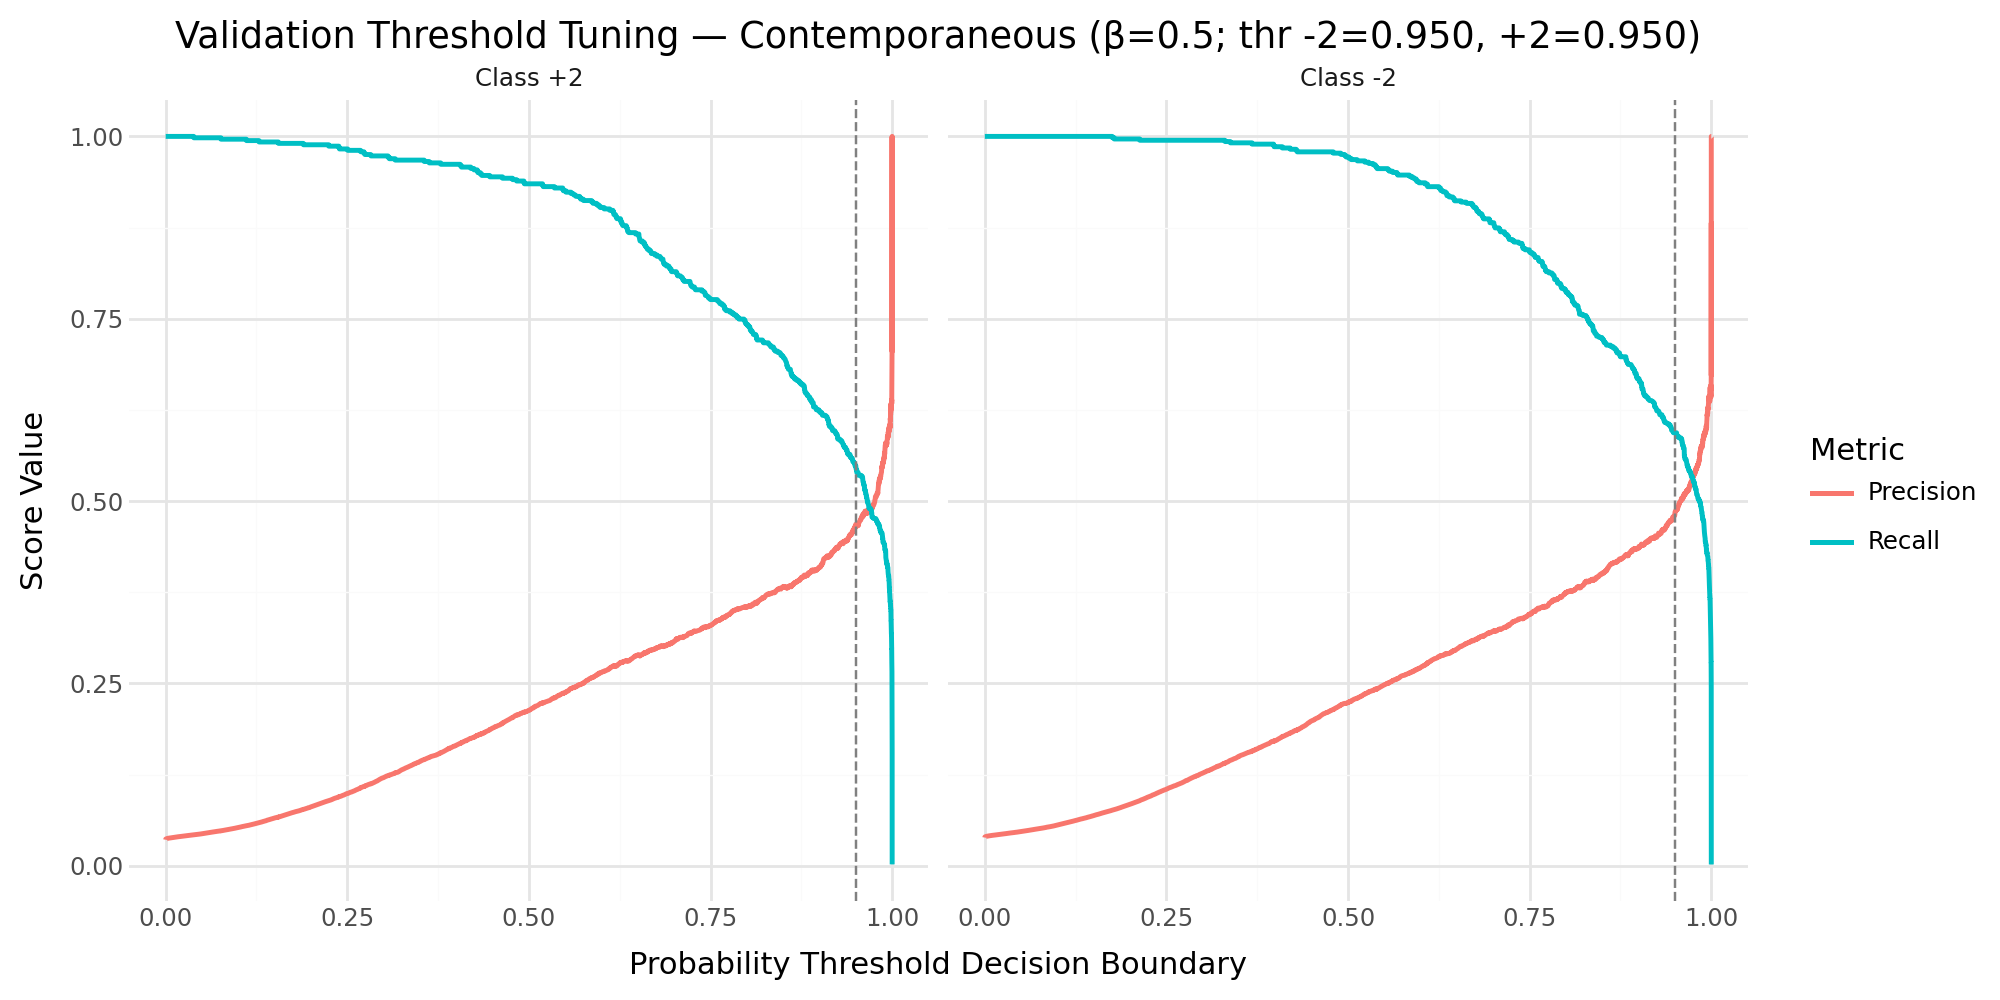

In [10]:
# --- Tune the per-tail decision thresholds on VALIDATION (2024) -------------
# Tune the -2 and +2 boundaries INDEPENDENTLY to maximise each tail's F-beta; compare the
# achieved macro-F-beta to naive arg-max-prob assignment.
y_val_c, probs_val_c = data_contemp['val']

THR_DOWN_C, THR_UP_C, fb_dn_c, fb_up_c = tune_thresholds(y_val_c, probs_val_c, beta=BETA)
argmax_fb_c = fbeta_score(y_val_c, np.array(CATS)[probs_val_c.argmax(1)],
                          beta=BETA, labels=CATS, average='macro', zero_division=0)
print(f'Validation tail thresholds (β={BETA}):  -2 → {THR_DOWN_C:.3f} (Fβ={fb_dn_c:.4f})  |  '
      f'+2 → {THR_UP_C:.3f} (Fβ={fb_up_c:.4f})   vs  arg-max-prob macro-Fβ = {argmax_fb_c:.4f}')

# Precision/Recall vs threshold on VALIDATION, with each tail's selected boundary marked.
pr_long_c = pr_threshold_df(y_val_c, probs_val_c)
thr_lines_c = pd.DataFrame({'Class': ['Class -2', 'Class +2'], 'thr': [THR_DOWN_C, THR_UP_C]})
(
    ggplot(pr_long_c, aes(x='Threshold', y='Value', color='Metric'))
    + geom_line(size=1)
    + geom_vline(aes(xintercept='thr'), data=thr_lines_c, linetype='dashed', color='grey')
    + facet_wrap('~Class', scales='free_x')
    + theme_minimal()
    + labs(
        title=f'Validation Threshold Tuning — Contemporaneous (β={BETA}; '
              f'thr -2={THR_DOWN_C:.3f}, +2={THR_UP_C:.3f})',
        x='Probability Threshold Decision Boundary',
        y='Score Value',
        color='Metric',
    )
    + theme(figure_size=(10, 5))
)


--- Contemporaneous | train (2021-2023) | thr=(-2:0.950, +2:0.950) | accuracy=0.8717 | n=62,386 ---
              precision    recall  f1-score   support

          -2       0.67      0.27      0.39      4492
           0       0.89      0.98      0.93     53178
          +2       0.65      0.27      0.38      4716

    accuracy                           0.87     62386
   macro avg       0.73      0.51      0.57     62386
weighted avg       0.85      0.87      0.85     62386


--- Contemporaneous | val (2024) | thr=(-2:0.950, +2:0.950) | accuracy=0.9214 | n=14,643 ---
              precision    recall  f1-score   support

          -2       0.48      0.59      0.53       566
           0       0.96      0.95      0.96     13554
          +2       0.47      0.55      0.50       523

    accuracy                           0.92     14643
   macro avg       0.64      0.70      0.66     14643
weighted avg       0.93      0.92      0.92     14643


--- Contemporaneous | test (2025) | thr=(-

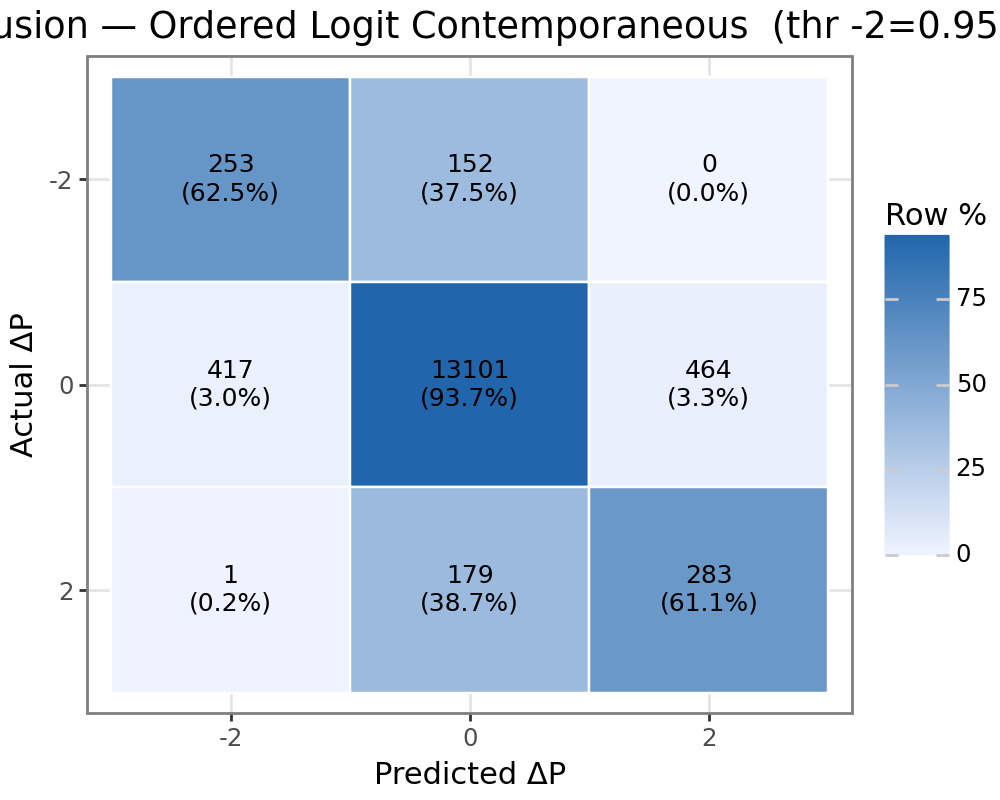

In [11]:
# --- Apply the validation-tuned thresholds: reports for all splits + TEST confusion matrix ---
# Train / val / test classification reports at the SAME validation-selected (THR_DOWN_C, THR_UP_C),
# then the held-out 2025 confusion matrix (raw counts + row %).
report_all_splits(data_contemp, THR_DOWN_C, THR_UP_C, 'Contemporaneous', split_labels=YEAR_LABEL)

y_test_c, probs_test_c = data_contemp['test']
confusion_tile(
    y_test_c, assign_classes(probs_test_c, THR_DOWN_C, THR_UP_C),
    title=f'Test (2025) Confusion — Ordered Logit Contemporaneous  '
          f'(thr -2={THR_DOWN_C:.3f}, +2={THR_UP_C:.3f})',
)

## Predictive Model: Ordered Logistic Regression (1-Step-Ahead)

Identical class-weighted ordered logit, but the target is $\Delta P_{t+1}$ — the next bin's
**cleaned** price change, shifted into the current row with `.shift(-1).over(['security', 'date'])`
in the cleaning step (before the split), so there is no look-ahead leakage across sessions or
years. Trained on 2021-2023, threshold tuned on validation (2024), evaluated on test (2025).

In [12]:
res_fwd, data_fwd, _ = fit_ordered_logit(
    df_signals_tc_clean, TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT,
    target_col='delta_p_fwd', label='Predictive 1-step (tick-constrained)', verbose=True,
)

=== Predictive 1-step (tick-constrained):  delta_p_fwd ~ obi + noi + stv  (train n=61,822, clusters=564, class_weight on ±2 = 11.3x) ===
train class counts: {-2: 4433, 0: 52717, 2: 4672}
                          WeightedOrderedModel Results                          
Dep. Variable:                        y   Log-Likelihood:            -1.4641e+05
Model:             WeightedOrderedModel   AIC:                         2.928e+05
Method:              Maximum Likelihood   BIC:                         2.929e+05
Date:                  Wed, 17 Jun 2026                                         
Time:                          10:55:17                                         
No. Observations:                 61822                                         
Df Residuals:                     61817                                         
Df Model:                             3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----

Validation tail thresholds (β=0.5):  -2 → 0.665 (Fβ=0.3088)  |  +2 → 0.715 (Fβ=0.3330)   vs  arg-max-prob macro-Fβ = 0.3951


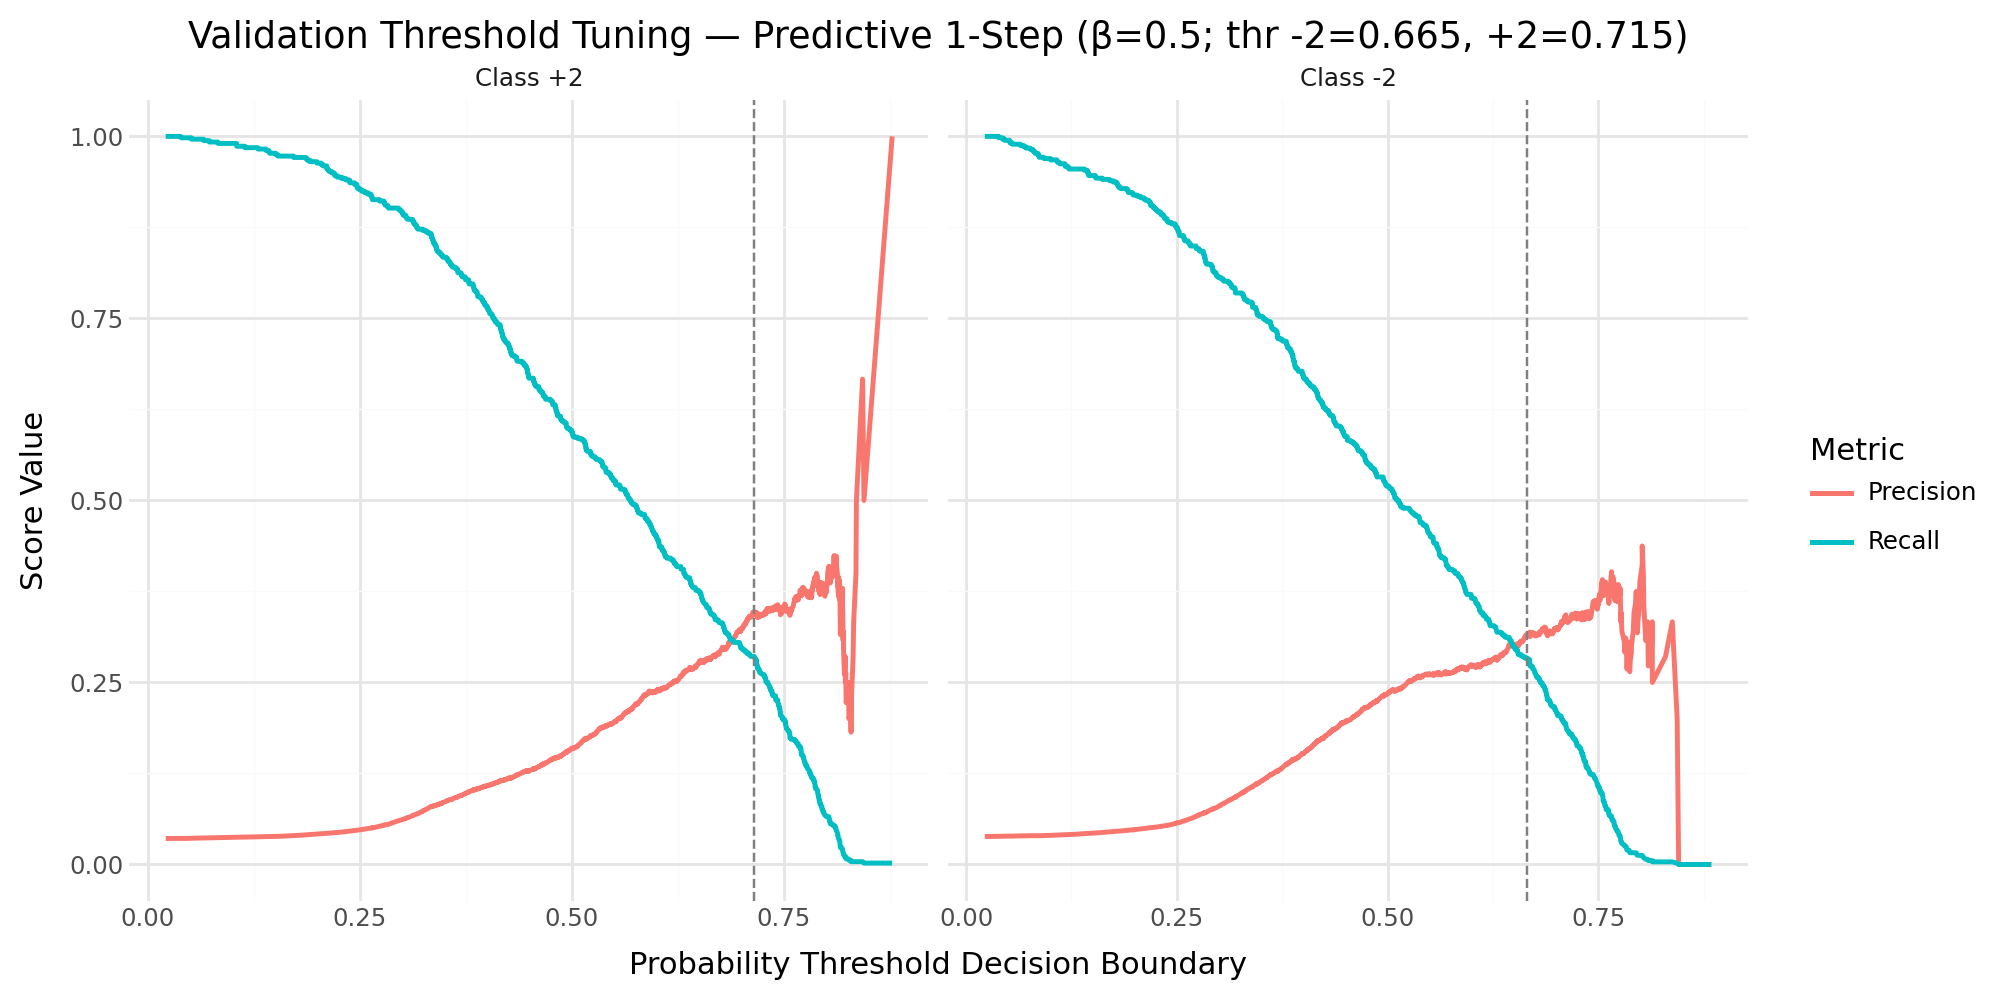

In [13]:
# --- Tune the predictive per-tail decision thresholds on VALIDATION (2024) --
y_val_f, probs_val_f = data_fwd['val']

THR_DOWN_F, THR_UP_F, fb_dn_f, fb_up_f = tune_thresholds(y_val_f, probs_val_f, beta=BETA)
argmax_fb_f = fbeta_score(y_val_f, np.array(CATS)[probs_val_f.argmax(1)],
                          beta=BETA, labels=CATS, average='macro', zero_division=0)
print(f'Validation tail thresholds (β={BETA}):  -2 → {THR_DOWN_F:.3f} (Fβ={fb_dn_f:.4f})  |  '
      f'+2 → {THR_UP_F:.3f} (Fβ={fb_up_f:.4f})   vs  arg-max-prob macro-Fβ = {argmax_fb_f:.4f}')

# Precision/Recall vs threshold on VALIDATION, with each tail's selected boundary marked.
pr_long_f = pr_threshold_df(y_val_f, probs_val_f)
thr_lines_f = pd.DataFrame({'Class': ['Class -2', 'Class +2'], 'thr': [THR_DOWN_F, THR_UP_F]})
(
    ggplot(pr_long_f, aes(x='Threshold', y='Value', color='Metric'))
    + geom_line(size=1)
    + geom_vline(aes(xintercept='thr'), data=thr_lines_f, linetype='dashed', color='grey')
    + facet_wrap('~Class', scales='free_x')
    + theme_minimal()
    + labs(
        title=f'Validation Threshold Tuning — Predictive 1-Step (β={BETA}; '
              f'thr -2={THR_DOWN_F:.3f}, +2={THR_UP_F:.3f})',
        x='Probability Threshold Decision Boundary',
        y='Score Value',
        color='Metric',
    )
    + theme(figure_size=(10, 5))
)


--- Predictive 1-step | train (2021-2023) | thr=(-2:0.665, +2:0.715) | accuracy=0.8110 | n=61,822 ---
              precision    recall  f1-score   support

          -2       0.28      0.24      0.26      4433
           0       0.87      0.91      0.89     52717
          +2       0.32      0.20      0.25      4672

    accuracy                           0.81     61822
   macro avg       0.49      0.45      0.47     61822
weighted avg       0.79      0.81      0.80     61822


--- Predictive 1-step | val (2024) | thr=(-2:0.665, +2:0.715) | accuracy=0.9049 | n=14,509 ---
              precision    recall  f1-score   support

          -2       0.32      0.28      0.30       558
           0       0.94      0.95      0.95     13433
          +2       0.35      0.29      0.31       518

    accuracy                           0.90     14509
   macro avg       0.54      0.51      0.52     14509
weighted avg       0.90      0.90      0.90     14509


--- Predictive 1-step | test (2025) | 

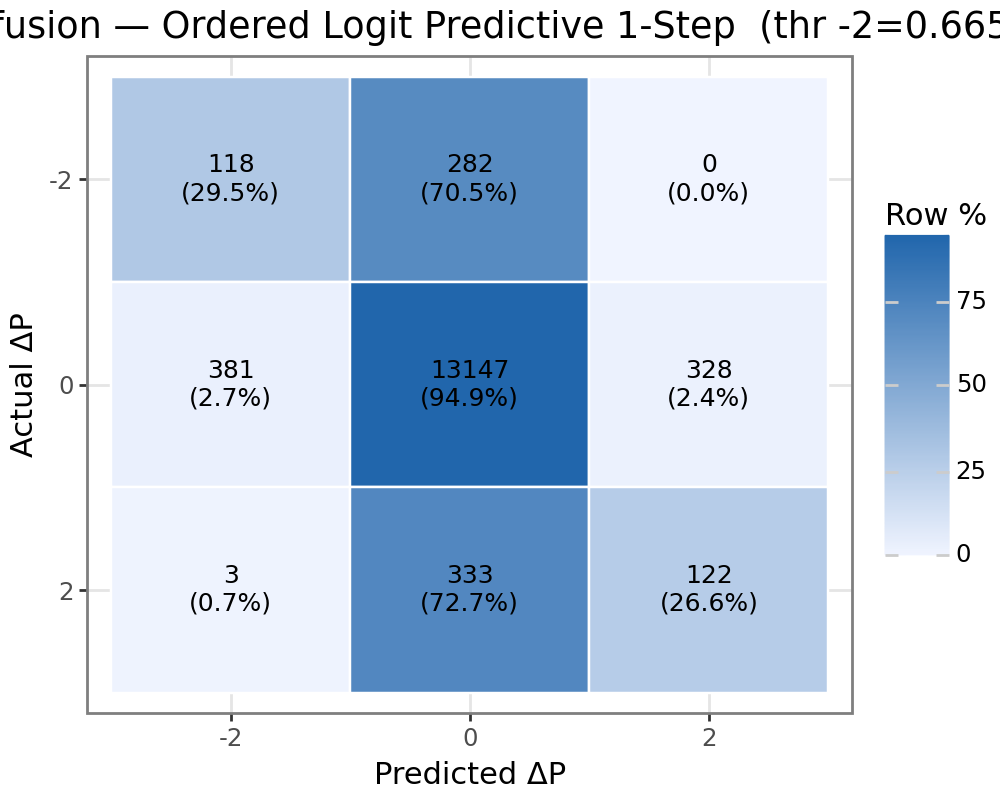

In [14]:
# --- Apply the validation-tuned thresholds: reports for all splits + TEST confusion matrix ---
report_all_splits(data_fwd, THR_DOWN_F, THR_UP_F, 'Predictive 1-step', split_labels=YEAR_LABEL)

y_test_f, probs_test_f = data_fwd['test']
confusion_tile(
    y_test_f, assign_classes(probs_test_f, THR_DOWN_F, THR_UP_F),
    title=f'Test (2025) Confusion — Ordered Logit Predictive 1-Step  '
          f'(thr -2={THR_DOWN_F:.3f}, +2={THR_UP_F:.3f})',
)

### Cross-`qcode` performance of the predictive model

The split-level reports above pool every tick-constrained curve group together. To check whether
the 1-step-ahead model is uniformly useful or only works on a subset, we break the **test (2025)**
tail performance out **by `qcode`**. The $+2$ and $-2$ classes are symmetric, so for each group
we report the **mean precision** and **mean recall** over the two tails (using the same fitted
model `res_fwd` and the same validation-tuned thresholds `THR_DOWN_F` / `THR_UP_F`). Groups are
ordered best → worst by $\tfrac12(\text{precision} + \text{recall})$; `tail_support` is the count
of actual $\pm2$ events, so thin bars on tiny support should be read with caution.

qcode  Precision   Recall  tail_support    n   MeanPR
   FX   0.352384 0.361415           205 1872 0.356899
   GM   0.353885 0.294872            81 1755 0.324378
   GX   0.431217 0.213725            64 1638 0.322471
   IE   0.302782 0.279786           155 1547 0.291284
   GH   0.293182 0.245449           110 1638 0.269315
   SV   0.163509 0.280457           207 4275 0.221983
   BF   0.054233 0.055728            36 1989 0.054980


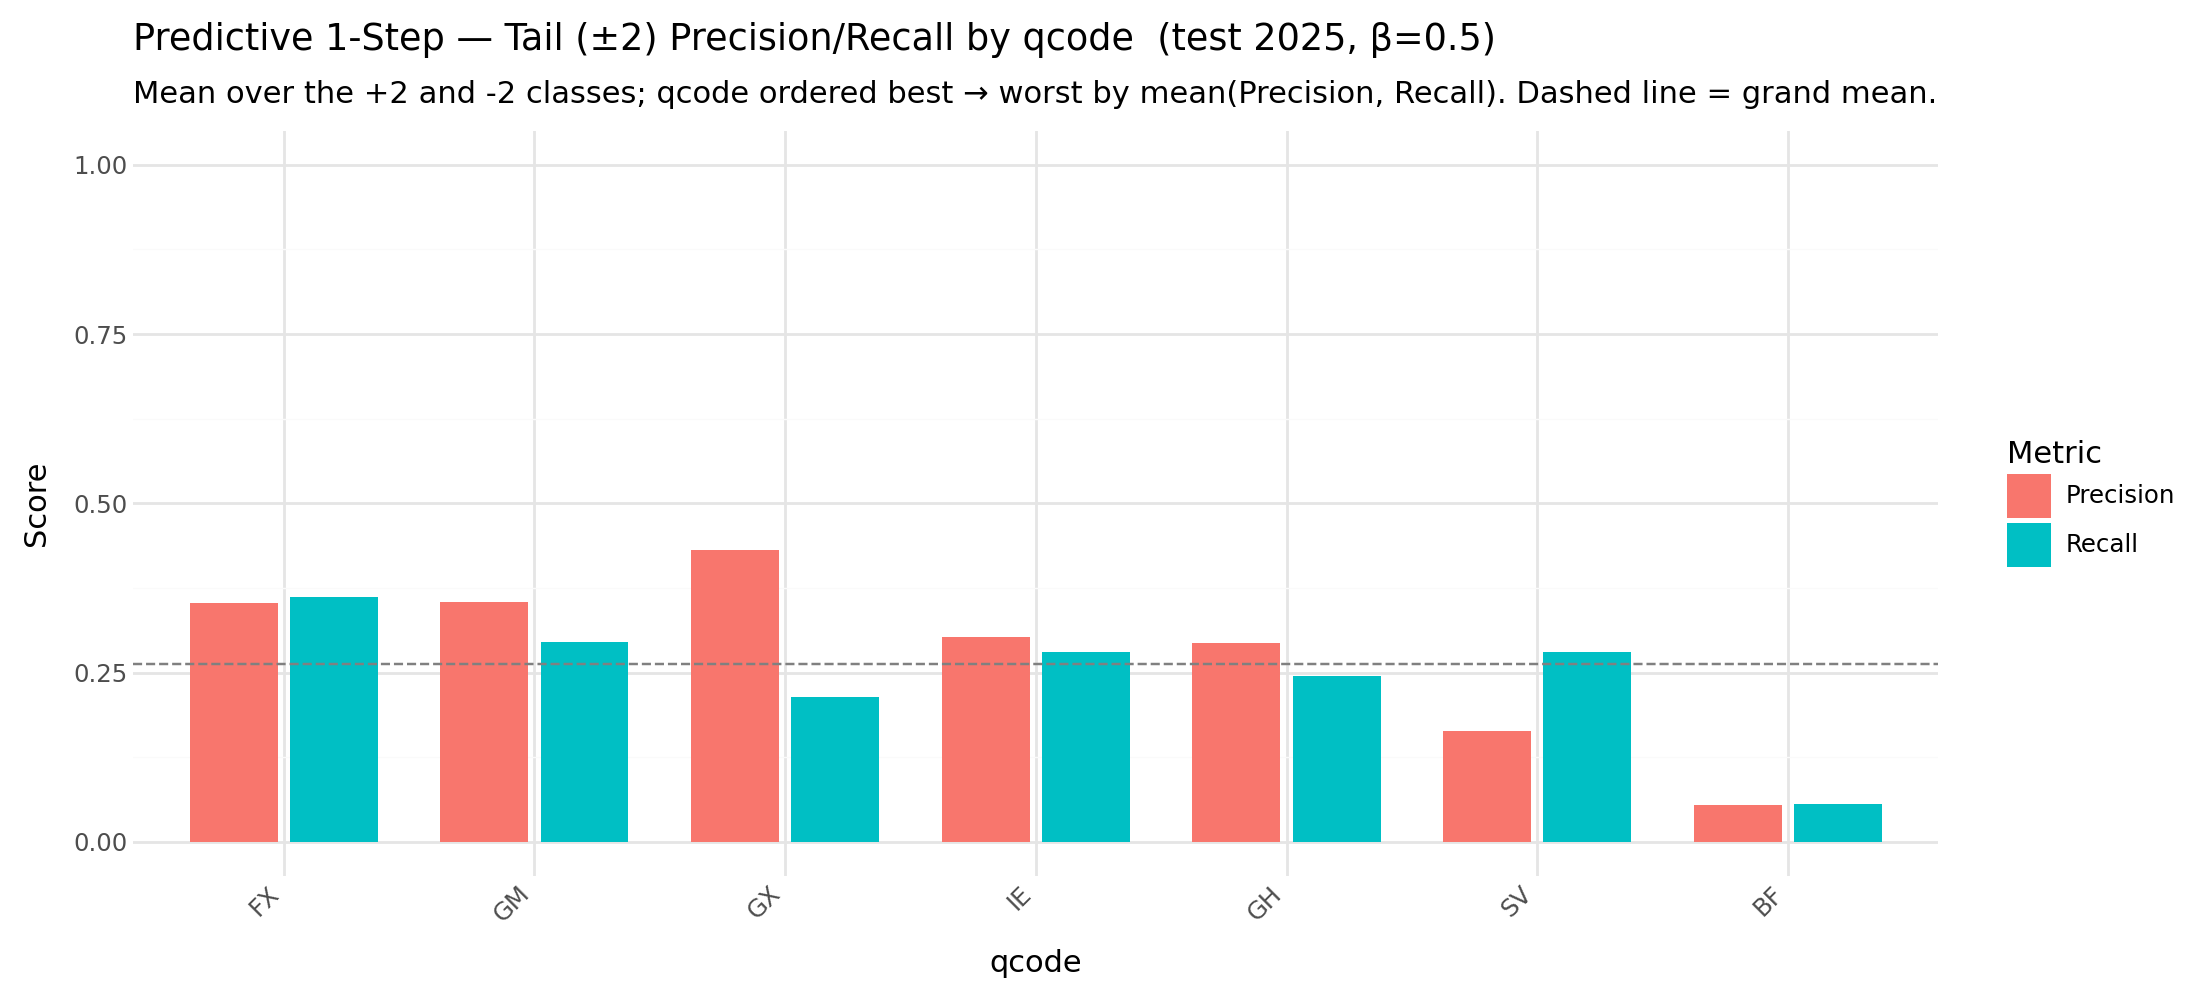

In [15]:
# --- Per-qcode evaluation of the predictive model on TEST (2025) ----------
# Tail (+/-2) precision & recall, averaged over the two tail classes (they are symmetric),
# computed SEPARATELY for each qcode so we can see where the 1-step-ahead model
# generalises and where it degrades. Uses the SAME fitted model (res_fwd) and the SAME
# validation-tuned (THR_DOWN_F, THR_UP_F); we just re-materialise the test slice carrying
# qcode so every row can be grouped.
from sklearn.metrics import precision_recall_fscore_support

_pdf_bbg = (
    df_signals_tc_clean
    .filter(pl.col('date').dt.year().is_in(TEST_YEARS))
    .select(['delta_p_fwd', *TC_FEATURES, 'qcode'])
    .drop_nulls()
    .to_pandas()
)
_pdf_bbg['y']    = _pdf_bbg['delta_p_fwd'].astype(int)
_pdf_bbg['pred'] = assign_classes(
    np.asarray(res_fwd.predict(exog=_pdf_bbg[TC_FEATURES])), THR_DOWN_F, THR_UP_F
)

rows = []
for code, g in _pdf_bbg.groupby('qcode'):
    prec, rec, _, sup = precision_recall_fscore_support(
        g['y'], g['pred'], labels=[-2, 2], zero_division=0,
    )
    rows.append({
        'qcode': code,
        'Precision': float(prec.mean()),   # mean over the +2 and -2 classes
        'Recall': float(rec.mean()),
        'tail_support': int(sup.sum()),    # # of actual +/-2 observations
        'n': int(len(g)),
    })

bbg_metrics = (
    pd.DataFrame(rows)
    .assign(MeanPR=lambda d: (d['Precision'] + d['Recall']) / 2)
    .sort_values('MeanPR', ascending=False)
    .reset_index(drop=True)
)
print(bbg_metrics.to_string(index=False))

# Dodged precision/recall bars, qcode ordered best -> worst by mean(Precision, Recall).
_order   = bbg_metrics['qcode'].tolist()
_grand   = bbg_metrics[['Precision', 'Recall']].to_numpy().mean()
bbg_long = bbg_metrics.melt(
    id_vars=['qcode'], value_vars=['Precision', 'Recall'],
    var_name='Metric', value_name='Value',
)
bbg_long['qcode'] = pd.Categorical(bbg_long['qcode'], categories=_order, ordered=True)
(
    ggplot(bbg_long, aes(x='qcode', y='Value', fill='Metric'))
    + geom_col(position=position_dodge(width=0.8), width=0.7)
    + geom_hline(yintercept=_grand, linetype='dashed', color='grey')
    + scale_y_continuous(limits=[0, 1])
    + labs(
        title=f'Predictive 1-Step — Tail (±2) Precision/Recall by qcode  '
              f'(test 2025, β={BETA})',
        subtitle='Mean over the +2 and -2 classes; qcode ordered best → worst by '
                 'mean(Precision, Recall). Dashed line = grand mean.',
        x='qcode', y='Score', fill='Metric',
    )
    + theme_minimal()
    + theme(figure_size=(11, 5), axis_text_x=element_text(rotation=45, hjust=1))
)

## Predictive Model + Outright Legs: Ordered Logit (1-Step-Ahead, 6 Features)

The same class-weighted ordered logit and out-of-sample protocol as the predictive model above,
but the feature set is augmented with the **outright legs' microstructure**. Alongside the
spread's own $OBI_t$ / $STV_t$ we add the normalised $OBI$ / $STV$ of the **buy** and **sell**
legs — resolved per `qcode` from `IS_CONVENTION_BUY_NEAR` (buy = near or far leg accordingly) and
joined on the matching `[date, bin_start_time]` — giving six features:

$$\mathbf{x}_t = [\,OBI_t,\ STV_t,\ OBI^{\text{buy}}_t,\ STV^{\text{buy}}_t,\ OBI^{\text{sell}}_t,\ STV^{\text{sell}}_t\,].$$

**Economic prior:** a quote/flow improvement on the **buy** leg should push the calendar-spread
price **up** ($+2$), and an improvement on the **sell** leg should push it **down** ($-2$).

Trained on 2021-2023, thresholds tuned on validation (2024), evaluated on test (2025) — reported
**pooled** and **per-`qcode`**. Bins where a leg signal is missing (leg outside its roll window)
are dropped by the fitter's `drop_nulls`, so this model is fit and scored on common leg-support.

In [19]:
LEG_FEATURES = ['obi', 'stv', 'buy_obi', 'buy_stv', 'sell_obi', 'sell_stv']
res_fwd_leg, data_fwd_leg, _ = fit_ordered_logit(
    df_signals_tc_clean, TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT,
    target_col='delta_p_fwd', feature_cols=LEG_FEATURES,
    label='Predictive 1-step + legs', verbose=True,
)

=== Predictive 1-step + legs:  delta_p_fwd ~ obi + stv + buy_obi + buy_stv + sell_obi + sell_stv  (train n=58,245, clusters=532, class_weight on ±2 = 11.7x) ===
train class counts: {-2: 4056, 0: 49919, 2: 4270}
                          WeightedOrderedModel Results                          
Dep. Variable:                        y   Log-Likelihood:            -1.3832e+05
Model:             WeightedOrderedModel   AIC:                         2.767e+05
Method:              Maximum Likelihood   BIC:                         2.767e+05
Date:                  Wed, 17 Jun 2026                                         
Time:                          10:57:32                                         
No. Observations:                 58245                                         
Df Residuals:                     58237                                         
Df Model:                             6                                         
                 coef    std err          z      P>|z|      

Validation tail thresholds (β=0.5):  -2 → 0.690 (Fβ=0.3085)  |  +2 → 0.715 (Fβ=0.3238)   vs  arg-max-prob macro-Fβ = 0.3944


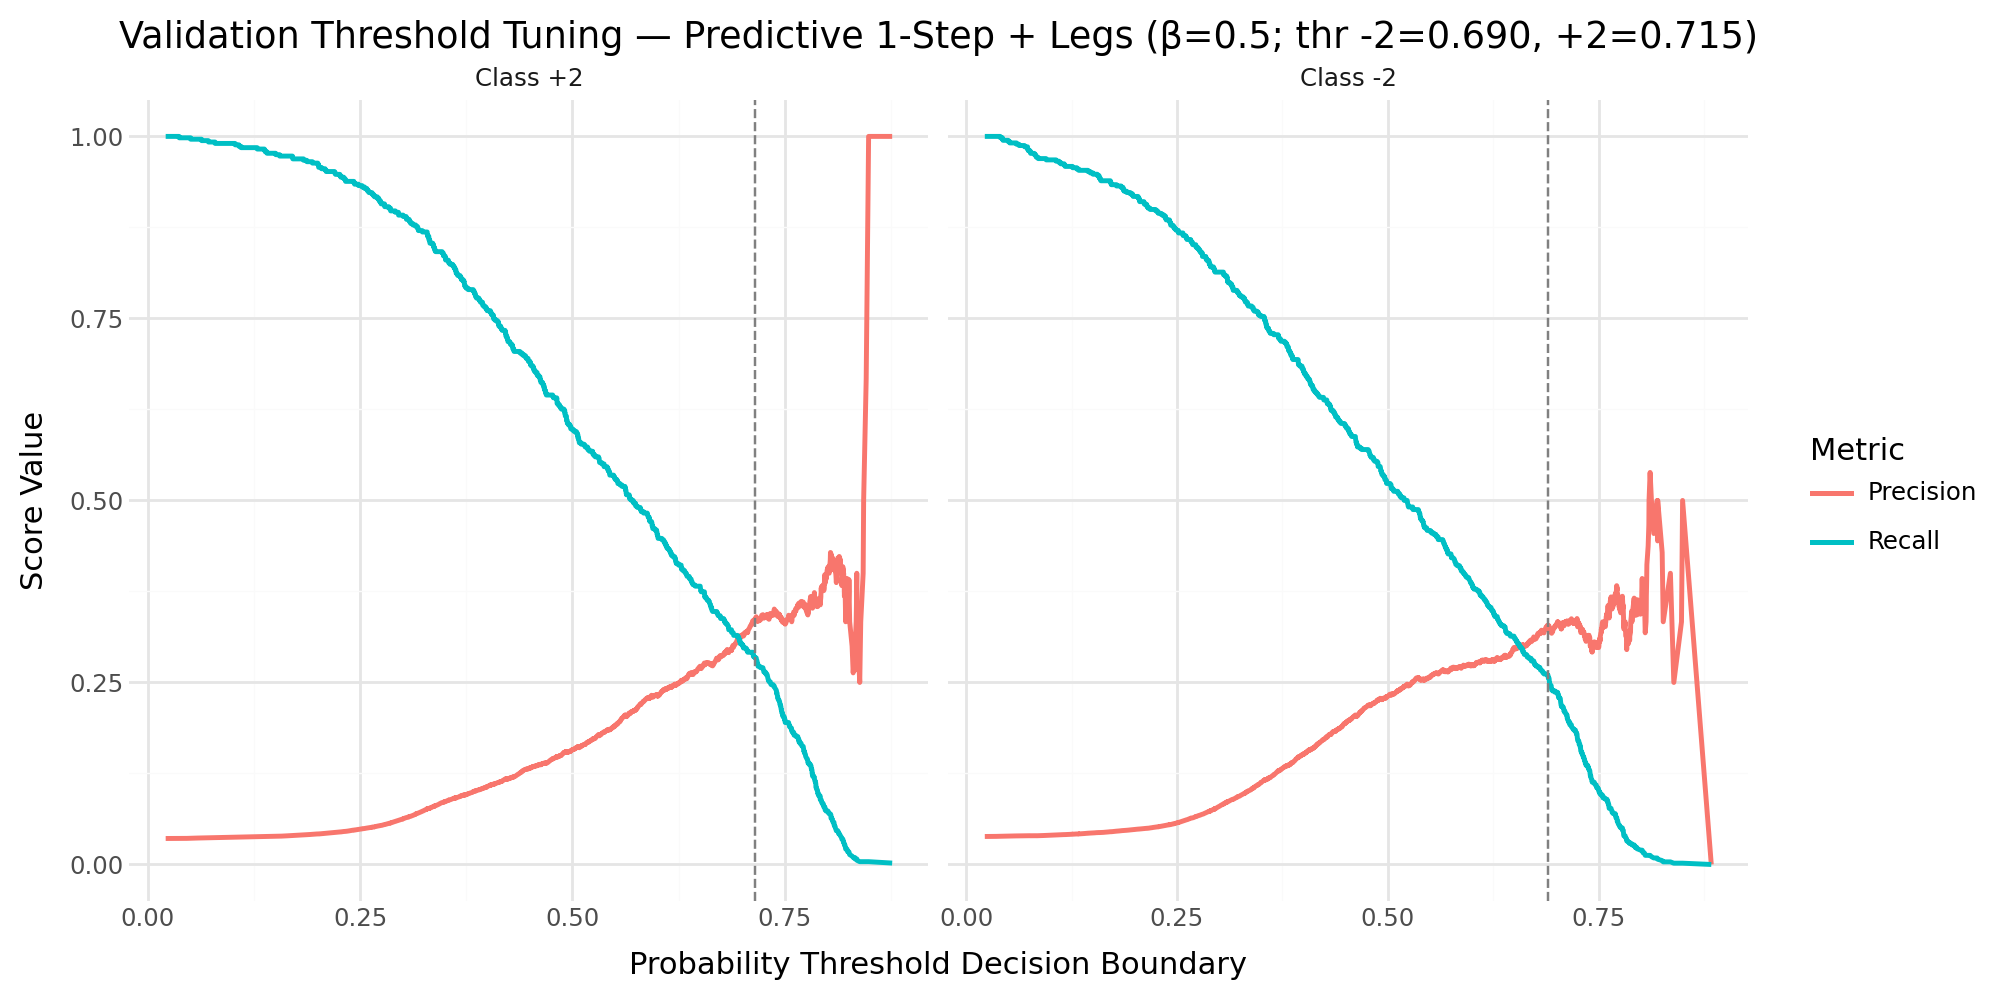

In [20]:
# --- Tune the leg-augmented per-tail decision thresholds on VALIDATION (2024) ---
y_val_fl, probs_val_fl = data_fwd_leg['val']

THR_DOWN_FL, THR_UP_FL, fb_dn_fl, fb_up_fl = tune_thresholds(y_val_fl, probs_val_fl, beta=BETA)
argmax_fb_fl = fbeta_score(y_val_fl, np.array(CATS)[probs_val_fl.argmax(1)],
                           beta=BETA, labels=CATS, average='macro', zero_division=0)
print(f'Validation tail thresholds (β={BETA}):  -2 → {THR_DOWN_FL:.3f} (Fβ={fb_dn_fl:.4f})  |  '
      f'+2 → {THR_UP_FL:.3f} (Fβ={fb_up_fl:.4f})   vs  arg-max-prob macro-Fβ = {argmax_fb_fl:.4f}')

# Precision/Recall vs threshold on VALIDATION, with each tail's selected boundary marked.
pr_long_fl = pr_threshold_df(y_val_fl, probs_val_fl)
thr_lines_fl = pd.DataFrame({'Class': ['Class -2', 'Class +2'], 'thr': [THR_DOWN_FL, THR_UP_FL]})
(
    ggplot(pr_long_fl, aes(x='Threshold', y='Value', color='Metric'))
    + geom_line(size=1)
    + geom_vline(aes(xintercept='thr'), data=thr_lines_fl, linetype='dashed', color='grey')
    + facet_wrap('~Class', scales='free_x')
    + theme_minimal()
    + labs(
        title=f'Validation Threshold Tuning — Predictive 1-Step + Legs (β={BETA}; '
              f'thr -2={THR_DOWN_FL:.3f}, +2={THR_UP_FL:.3f})',
        x='Probability Threshold Decision Boundary',
        y='Score Value',
        color='Metric',
    )
    + theme(figure_size=(10, 5))
)


--- Predictive 1-step + legs | train (2021-2023) | thr=(-2:0.690, +2:0.715) | accuracy=0.8202 | n=58,245 ---
              precision    recall  f1-score   support

          -2       0.29      0.20      0.23      4056
           0       0.88      0.92      0.90     49919
          +2       0.31      0.21      0.25      4270

    accuracy                           0.82     58245
   macro avg       0.49      0.44      0.46     58245
weighted avg       0.79      0.82      0.81     58245


--- Predictive 1-step + legs | val (2024) | thr=(-2:0.690, +2:0.715) | accuracy=0.9059 | n=14,509 ---
              precision    recall  f1-score   support

          -2       0.33      0.26      0.29       558
           0       0.94      0.96      0.95     13433
          +2       0.34      0.28      0.31       518

    accuracy                           0.91     14509
   macro avg       0.53      0.50      0.51     14509
weighted avg       0.90      0.91      0.90     14509


--- Predictive 1-step + 

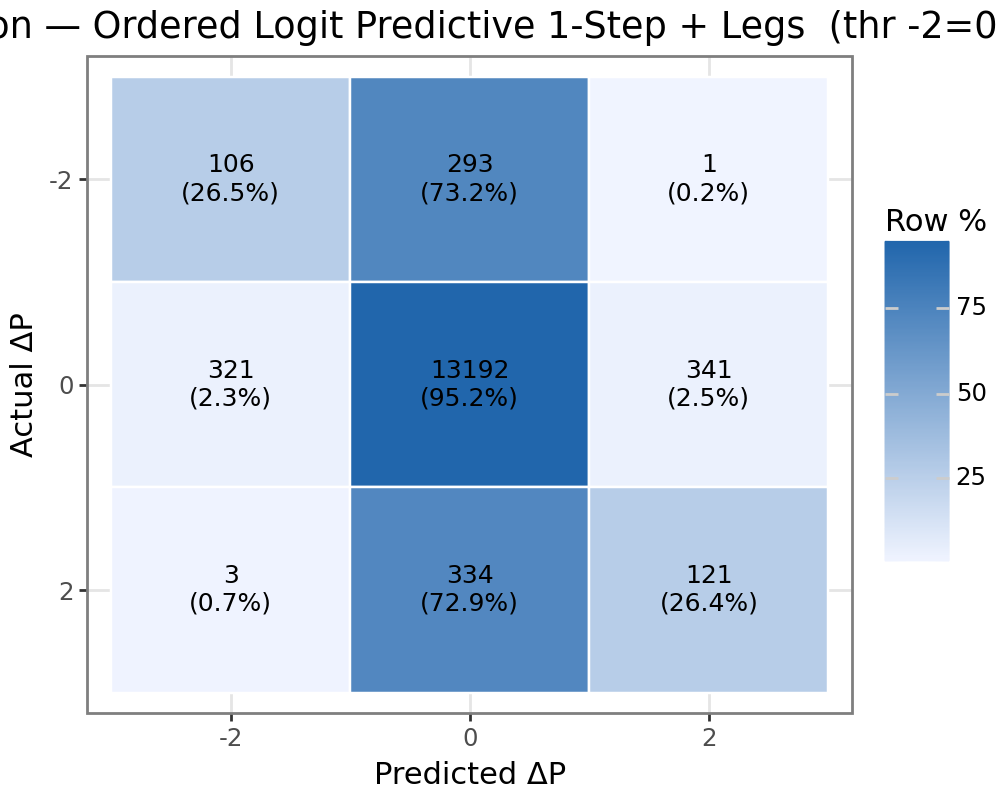

In [21]:
# --- Pooled evaluation: reports for all splits + TEST confusion matrix ------
report_all_splits(data_fwd_leg, THR_DOWN_FL, THR_UP_FL, 'Predictive 1-step + legs',
                  split_labels=YEAR_LABEL)

y_test_fl, probs_test_fl = data_fwd_leg['test']
confusion_tile(
    y_test_fl, assign_classes(probs_test_fl, THR_DOWN_FL, THR_UP_FL),
    title=f'Test (2025) Confusion — Ordered Logit Predictive 1-Step + Legs  '
          f'(thr -2={THR_DOWN_FL:.3f}, +2={THR_UP_FL:.3f})',
)

### Cross-`qcode` comparison: does adding the legs help?

To isolate the **incremental** value of the outright-leg features, both models are scored on the
**same test (2025) rows** — those where every leg feature is present, so the 6-feature model is
defined (`common leg-support`). For each `qcode` we report the tail ($\pm2$) **mean precision /
recall**, then compare the base 3-feature predictive model against the leg-augmented 6-feature
one. A positive `Delta` means the legs improve that curve group; this surfaces where the
buy/sell-leg microstructure carries genuine predictive signal versus where it adds nothing.

Model  +Legs (6f)  Base (3f)  Delta
qcode                              
GX          0.396      0.431 -0.035
FX          0.358      0.352  0.005
GM          0.349      0.354 -0.005
GH          0.306      0.293  0.012
IE          0.294      0.304 -0.010
SV          0.161      0.164 -0.003
BF          0.056      0.054  0.002


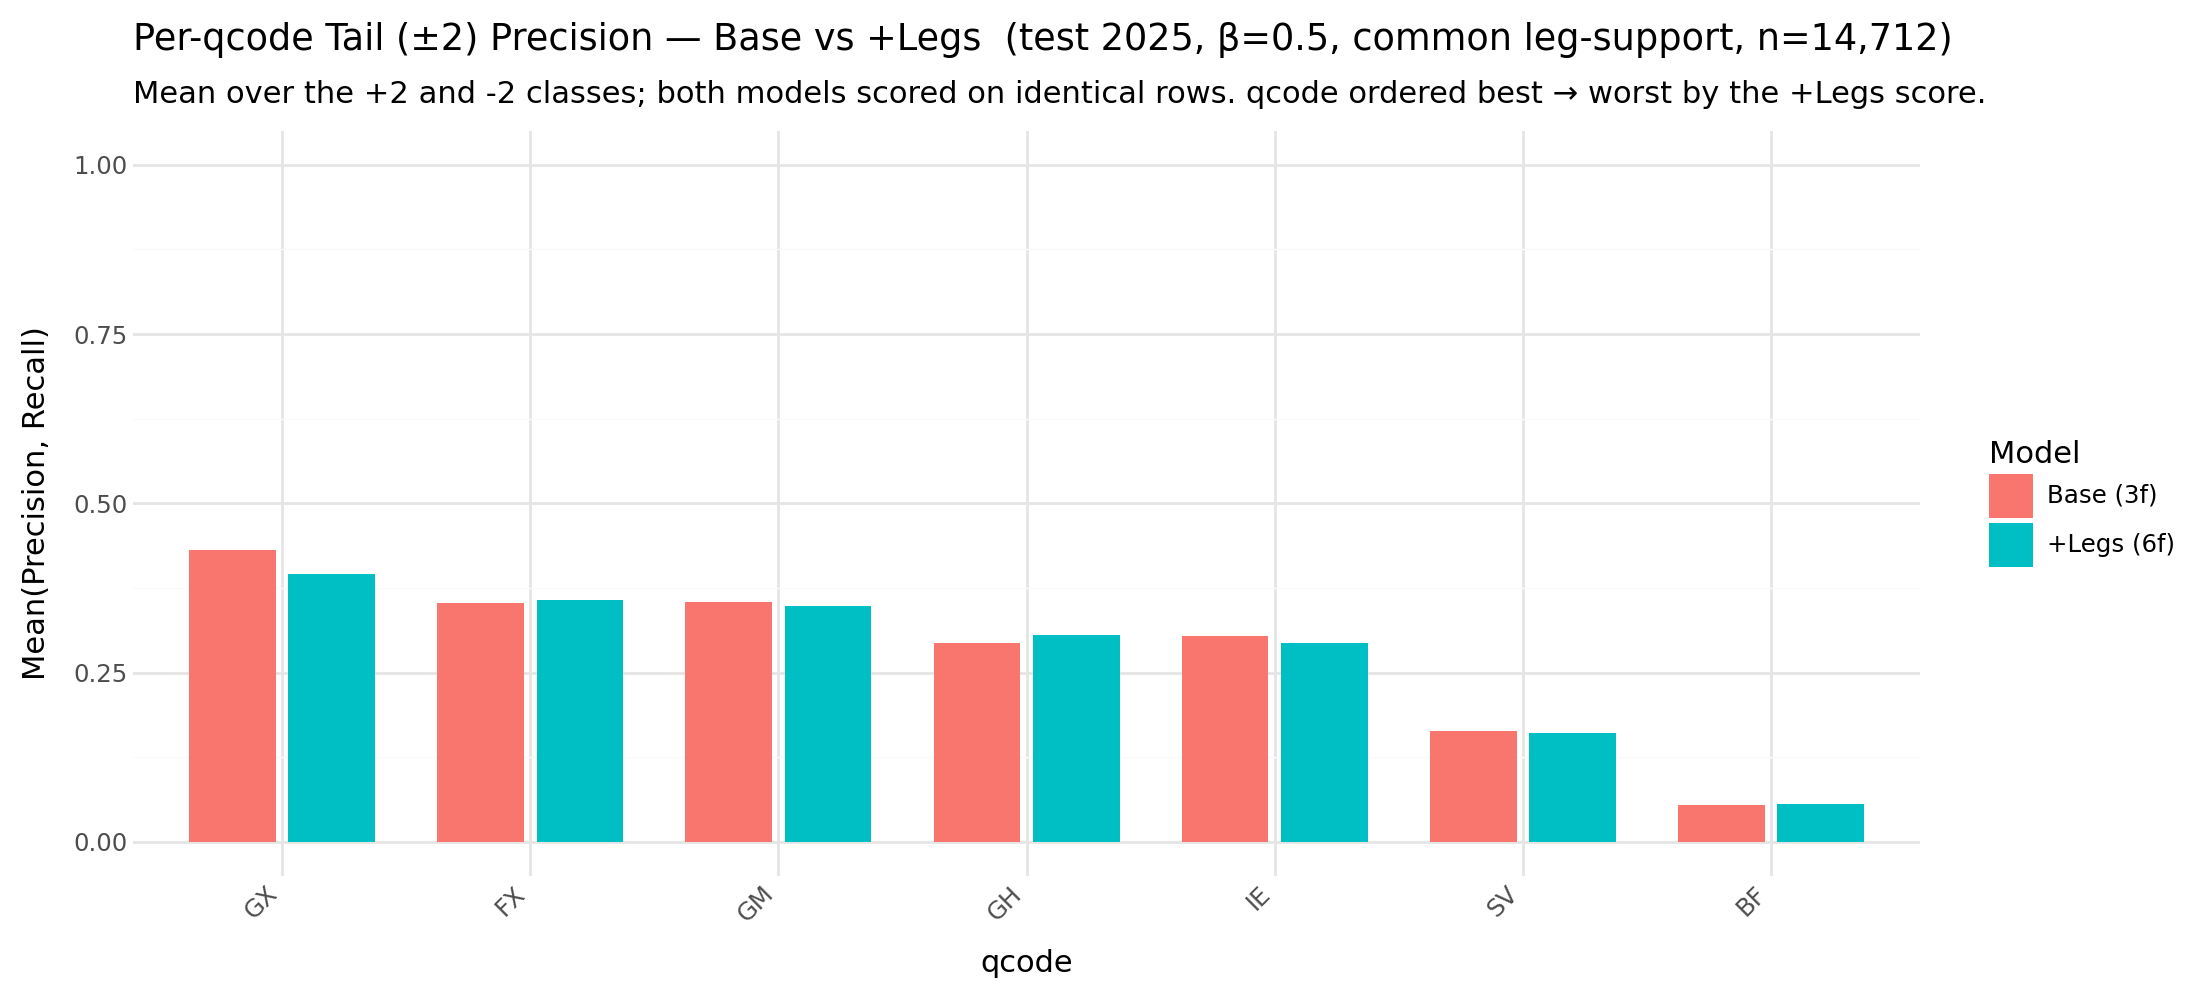

In [22]:
# --- Per-qcode: base (3f) vs leg-augmented (6f) on COMMON leg-support (test 2025) ---
# Both models are scored on the SAME rows (every leg feature present) so the comparison
# reflects only the added features, not a change in the evaluated sample. Each model uses its
# OWN validation-tuned per-tail thresholds. Tail (+/-2) precision/recall are averaged over the
# two symmetric classes within each qcode.
ALL_FEATS = sorted(set(TC_FEATURES) | set(LEG_FEATURES))   # union: obi, noi, stv, buy_*, sell_*

_cmp = (
    df_signals_tc_clean
    .filter(pl.col('date').dt.year().is_in(TEST_YEARS))
    .select(['delta_p_fwd', *ALL_FEATS, 'qcode'])
    .drop_nulls()
    .to_pandas()
)
_cmp['y'] = _cmp['delta_p_fwd'].astype(int)
_cmp['pred_base'] = assign_classes(
    np.asarray(res_fwd.predict(exog=_cmp[TC_FEATURES])), THR_DOWN_F, THR_UP_F)
_cmp['pred_leg']  = assign_classes(
    np.asarray(res_fwd_leg.predict(exog=_cmp[LEG_FEATURES])), THR_DOWN_FL, THR_UP_FL)


def _tail_pr(g, pred_col):
    """Mean precision/recall over the two tail classes (+/-2) for one qcode group."""
    prec, rec, _, sup = precision_recall_fscore_support(
        g['y'], g[pred_col], labels=[-2, 2], zero_division=0)
    return {'Precision': float(prec.mean()), 'Recall': float(rec.mean()),
            'MeanPR': float((prec.mean() + rec.mean()) / 2), 'tail_support': int(sup.sum())}

rows = []
for code, g in _cmp.groupby('qcode'):
    for model, pc in (('Base (3f)', 'pred_base'), ('+Legs (6f)', 'pred_leg')):
        rows.append({'qcode': code, 'Model': model, **_tail_pr(g, pc), 'n': int(len(g))})
cmp_metrics = pd.DataFrame(rows)

# Wide MeanPR table with the base -> legs delta, ordered by the leg model.
wide = (
    cmp_metrics.pivot_table(index='qcode', columns='Model', values='Precision')
    .assign(Delta=lambda d: d['+Legs (6f)'] - d['Base (3f)'])
    .sort_values('+Legs (6f)', ascending=False)
)
print(wide.to_string(float_format=lambda x: f'{x:.3f}'))

# Dodged bars: base vs legs per qcode (ordered best -> worst by the leg model's MeanPR).
_order = wide.index.tolist()
cmp_metrics['qcode'] = pd.Categorical(cmp_metrics['qcode'], categories=_order, ordered=True)
cmp_metrics['Model'] = pd.Categorical(cmp_metrics['Model'], categories=['Base (3f)', '+Legs (6f)'])
(
    ggplot(cmp_metrics, aes(x='qcode', y='Precision', fill='Model'))
    + geom_col(position=position_dodge(width=0.8), width=0.7)
    + scale_y_continuous(limits=[0, 1])
    + labs(
        title=f'Per-qcode Tail (±2) Precision — Base vs +Legs  '
              f'(test 2025, β={BETA}, common leg-support, n={len(_cmp):,})',
        subtitle='Mean over the +2 and -2 classes; both models scored on identical rows. '
                 'qcode ordered best → worst by the +Legs score.',
        x='qcode', y='Mean(Precision, Recall)', fill='Model',
    )
    + theme_minimal()
    + theme(figure_size=(11, 5), axis_text_x=element_text(rotation=45, hjust=1))
)